In [17]:
import os 
from dotenv import load_dotenv
load_dotenv()
api_key = os.getenv("GEMINI_API_KEY")

In [18]:
#State Schema
from typing import Annotated, Sequence, TypedDict

from langchain_core.messages import BaseMessage
from langgraph.graph.message import add_messages #Reducers for adding messages instead of replacement

In [19]:
#Defining the State Schema
class AgentState(TypedDict):
    "The state schema of the agent"
    messages: Annotated[Sequence[BaseMessage], add_messages]
    number_of_steps: int

In [ ]:
# Defining the Weather tool

from langchain_core.tools import tool
from geopy.geocoders import Nominatim
from pydantic import BaseModel, Field
import requests

geolocator = Nominatim(user_agent="weather-app")

class SearchInput(BaseModel):
    location:str = Field(description="The city and state",example = "San Francisco")
    date:str = Field(description = "The Forecasting date for when to get the weather format (yyyy-mm-dd)")

@tool("get_weather_forecast", args_schema=SearchInput, return_direct = True)
def get_weather_forecast(location: str, date: str):
    """
    Retrieves the weather using Open Metro API.
    Takes the location and a date
    Return: 
        A dict with the time and temperature for each hour.
    """
    location = geolocator.geocode(location)
    if location:
        try:
            response = requests.get(f"https://api.open-meteo.com/v1/forecast?latitude={location.latitude}&longitude={location.longitude}&hourly=temperature_2m&start_date={date}&end_date={date}")
            data = response.json()
            return dict(zip(data["hourly"]["time"], data["hourly"]["temperature_2m"]))
        except Exception as e:
            return {"error": str(e)}
    else:
        return {"error": "Location Not Found!"}
#Adding the weather tool made just now to the list of tools
tools = [get_weather_forecast]

/tmp/ipykernel_6406/489879544.py:11: PydanticDeprecatedSince20: Using extra keyword arguments on `Field` is deprecated and will be removed. Use `json_schema_extra` instead. (Extra keys: 'example'). Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.13/migration/
  location:str = Field(description="The city and state",example = "San Francisco")


In [21]:
#initialize the model and binding tools with the model
from datetime import datetime
from langchain_google_genai import ChatGoogleGenerativeAI

#Create the LLM Node
llm = ChatGoogleGenerativeAI(
    model = "gemini-3-flash-preview",
    temperature = 1.0,
    max_retries = 2,
    google_api_key = api_key,
)

#Binding Tools to the model
model = llm.bind_tools([get_weather_forecast])

#Test the model with tools
res = model.invoke(f"What is the weather in Berlin on {datetime.today()}?")

print(res)

content=[] additional_kwargs={'function_call': {'name': 'get_weather_forecast', 'arguments': '{"location": "Berlin", "date": "2026-05-16"}'}, '__gemini_function_call_thought_signatures__': {'11e690d5-bce3-4cc8-9f48-9b1d9a826df0': 'EsgDCsUDAQw51se32Fa5lxXVsoPczBlDE3lN+QfRaha9aQ8iV7dZo8+xwehVQMS5MsAz2LfdYgEqvXGNHI7OAetZRmRcNUo8mJNwTWS2cfR2hkwr6GvlWo7r9qyrnidqlht0hmYlV9Wasw8gY8xSZqU5k2uxyY+IjsMt2DfDip90gR9xn1t5+oov6kXBaj2v8ZKcV/WvzkP45ChynCz0f7XCN7pI9SroLv2Gcuieu+fIHAw1dfN1btyo5qp1qTx6eVtX2Izu7dnPCZFhPhkpWRZZeKj8LUsrLtLPqXtiqZUZKhbnOKvLMBkeD7QPNq4RhppMjWxXg0TkZ8gfGNL0wKT9NulKWl+gRqEgXsVX+32VYHzHBlFOvQPNxMaYQYyuYOL+a+D2lg1pSqlbXxiqWlwNSjeC1Hx5oHILHxqs6hNJRyYwYp4Elof/f1JrgIajPmLx34UZ7kb5X14AlaxX1mu4/HpQY1VVnh6uzt3/UMLAOOx1fY2JHZZnJmx1IPmJJxG2RPNZlTh+p71Wv3wyF4VWgEL2MtsK7qqP+M/mWLrcX8tR2fmmMa8f6oFzYWgayenUdROn/kaHcisbm648oknp/bsVaToV8EC2'}} response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3-flash-preview', 'safety_ratings': [], 'model_provider': 'google_genai'} id='lc_run--0

In [36]:
#Defining Nodes and Edges of the Graph
from langchain_core.messages import ToolMessage
from langchain_core.runnables import RunnableConfig

tools_by_name = {tool.name: tool for tool in tools}

#Defining tool node
def call_tool(state: AgentState):
    outputs = []
    #Iterating over tool calls in the last message
    for tool_call in state["messages"][-1].tool_calls:
        #Get tool by name
        tool_result = tools_by_name[tool_call["name"]].invoke(tool_call["args"])
        outputs.append(
            ToolMessage(
                content = tool_result,
                name = tool_call["name"],
                tool_call_id = tool_call["id"],
            )
        )
    return {"messages": outputs}

def call_model(state: AgentState, config: RunnableConfig,):
    #Invoking the model with system prompt and the messages
    response = model.invoke(state["messages"], config)
    #This returns a list which combines with the existing messages state using the add_message reducer
    return {"messages": [response]}


#Defining the conditional edge that determines whether to continue or not
def should_continue(state: AgentState):
    message = state["messages"]
    #If the last message is not a tool call then finish
    if not state["messages"][-1].tool_calls:
        return "end"
    #default to continue
    return "continue"

In [37]:
#Assembling the components of the agent 
from langgraph.graph import StateGraph, END

#Define a new graph with our state
workflow = StateGraph(AgentState)

#Adding nodes
workflow.add_node("llm", call_model)
workflow.add_node("tools", call_tool)
#Setting entrypoint as 'agent' this is the first node called
workflow.set_entry_point("llm")
#Adding conditional edge after the llm node is created
workflow.add_conditional_edges(
    #Edge after 'agent' is called
    "llm",
    #Condiitonal node will decide
    should_continue,
    {
        #if 'tools' called then call the tool node
        "continue": "tools",
        #Otherwise we finish
        "end": END,
    },
)
#Normal edge after 'tools' is called, We call 'llm' again
workflow.add_edge("tools", "llm")
#Compile
graph = workflow.compile()


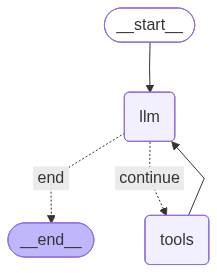

In [38]:
#Visualising 
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [39]:
#running the agent
from datetime import datetime
from langchain_core.messages import HumanMessage
#Creating initial message dictionary
inputs = {"messages":[HumanMessage(content=f"What is the weather in Berlin on {datetime.today()} ?")],
        "number_of_steps": 0,}

#Calling the graph with streaming to see the steps
for state in graph.stream(inputs, stream_mode = "values"):
    last_message = state["messages"][-1]
    last_message.pretty_print()

================================ Human Message =================================

What is the weather in Berlin on 2026-05-16 18:05:03.797396 ?
================================== Ai Message ==================================

[]
Tool Calls:
  get_weather_forecast (dd292e4a-d2f6-4828-8334-8c73cb81c4de)
 Call ID: dd292e4a-d2f6-4828-8334-8c73cb81c4de
  Args:
    date: 2026-05-16
    location: Berlin
================================= Tool Message =================================
Name: get_weather_forecast

{'2026-05-16T00:00': 9.8, '2026-05-16T01:00': 9.2, '2026-05-16T02:00': 8.1, '2026-05-16T03:00': 6.9, '2026-05-16T04:00': 6.5, '2026-05-16T05:00': 6.8, '2026-05-16T06:00': 8.1, '2026-05-16T07:00': 9.7, '2026-05-16T08:00': 11.3, '2026-05-16T09:00': 12.2, '2026-05-16T10:00': 13.0, '2026-05-16T11:00': 13.9, '2026-05-16T12:00': 14.7, '2026-05-16T13:00': 14.8, '2026-05-16T14:00': 14.3, '2026-05-16T15:00': 14.1, '2026-05-16T16:00': 14.2, '2026-05-16T17:00': 14.1, '2026-05-16T18:00': 13.1, '202

In [40]:
# Comparing with other cities
state["messages"].append(("user", "Would it be warmer in Munich?"))

for state in graph.stream(state, stream_mode="values"):
    last_message = state["messages"][-1]
    last_message.pretty_print()

================================ Human Message =================================

Would it be warmer in Munich?
================================== Ai Message ==================================

[]
Tool Calls:
  get_weather_forecast (1015f831-9839-4901-8275-72cff287ba25)
 Call ID: 1015f831-9839-4901-8275-72cff287ba25
  Args:
    date: 2026-05-16
    location: Munich
================================= Tool Message =================================
Name: get_weather_forecast

{'2026-05-16T00:00': 7.1, '2026-05-16T01:00': 7.1, '2026-05-16T02:00': 7.0, '2026-05-16T03:00': 7.0, '2026-05-16T04:00': 6.4, '2026-05-16T05:00': 6.3, '2026-05-16T06:00': 6.6, '2026-05-16T07:00': 7.2, '2026-05-16T08:00': 8.0, '2026-05-16T09:00': 8.8, '2026-05-16T10:00': 9.7, '2026-05-16T11:00': 10.2, '2026-05-16T12:00': 10.8, '2026-05-16T13:00': 12.2, '2026-05-16T14:00': 9.6, '2026-05-16T15:00': 10.3, '2026-05-16T16:00': 10.3, '2026-05-16T17:00': 10.7, '2026-05-16T18:00': 9.4, '2026-05-16T19:00': 9.0, '2026-05-16T20:0